# **SPECTRA v2**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import torch
import json
import networkx as nx
from matplotlib import pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
from torch_geometric.utils import from_networkx
import os

/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


In [3]:
# torch device setting
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(torch.version.cuda)
    print(torch.cuda.get_device_name())
else:
    device = torch.device('cpu')
print(device)

12.1
Tesla V100-SXM2-32GB
cuda


In [4]:
import pickle
with open("depmap/depmap_crispr_gene_effect_processed.pkl", "rb") as file:
    depmap = pickle.load(file)
len(depmap.keys())

18610

### **Data import**

In [4]:
# data loading and filtering
adata = sc.read_h5ad('../data/vcc_data/adata_Training.h5ad') #VCC
#adata = sc.read_h5ad('../data/replogle_k562_essential/perturb_processed.h5ad') # replogle
adata

AnnData object with n_obs × n_vars = 221273 × 18080
    obs: 'target_gene', 'guide_id', 'batch'
    var: 'gene_id'

In [ ]:
# Rename column and ctrl samples
adata.obs = adata.obs.rename(columns={"condition": "target_gene"})
adata.obs["target_gene"] = adata.obs["target_gene"].str.replace("ctrl", "non-targeting", regex=False)

# rename of single perturbations
adata.obs["target_gene"] = adata.obs["target_gene"].str.replace("ctrl", "non-targeting", regex=False)
adata.obs['target_gene'] = adata.obs['target_gene'].str.replace(r'\+non-targeting$', '', regex=True)

adata

AnnData object with n_obs × n_vars = 162751 × 5000
    obs: 'target_gene', 'cell_type', 'cov_drug_dose_name', 'dose_val', 'control', 'condition_name'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'

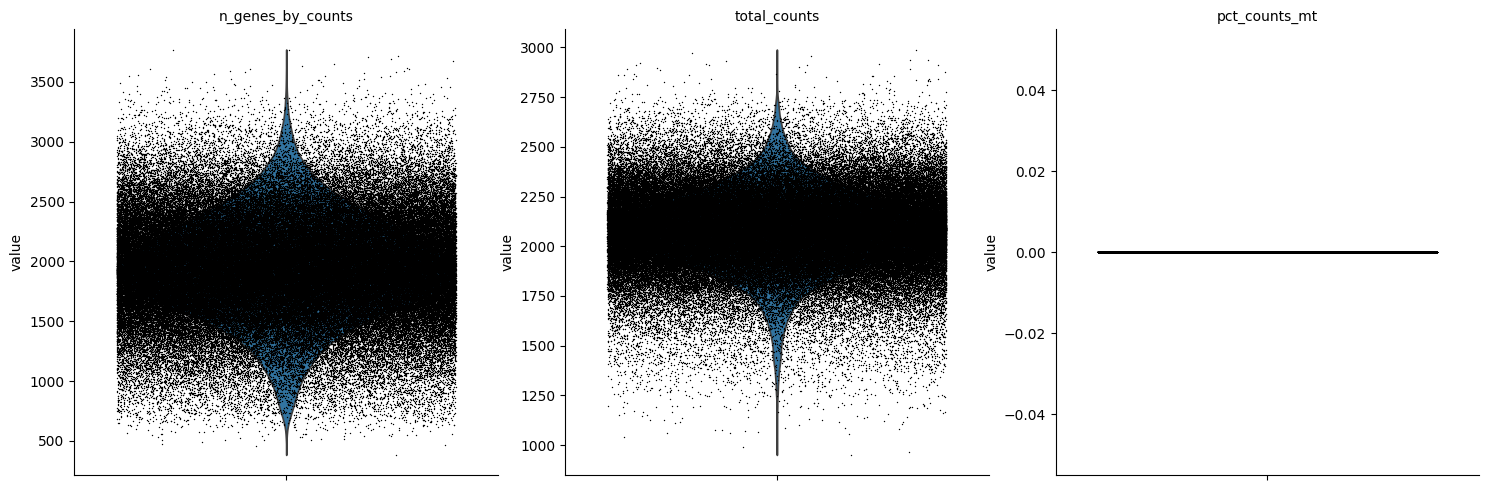

In [8]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [5]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3) # TODO: should be 3 but if so I would have to recalculate the GRN....
adata

AnnData object with n_obs × n_vars = 221273 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'

In [6]:
adata.raw = adata.copy() 
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)

# select only perturbations that are present in at least 200 cells
counts = adata.obs['target_gene'].value_counts()
valid_pert = counts[counts >= 200].index
adata = adata[adata.obs['target_gene'].isin(valid_pert)]
del counts
del valid_pert
adata

View of AnnData object with n_obs × n_vars = 219999 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

In [7]:
gene_list = adata.var_names.tolist()

### **GRN preparation**

***
### Patrick stuff

In [10]:
# patrick guanlab (stock)
A = np.load('Patrick_networks/guanlab_stock_3.5k_directed.npz')
adjacency = A['adjacency']
gene_names = A['gene_names']

# Create weighted DiGraph (parallel_edges=False treats values as weights)
G = nx.from_numpy_array(
    adjacency,
    parallel_edges=False,
    create_using=nx.DiGraph(),
    edge_attr='weight',  # Attribute name for weights
)

# Relabel nodes with gene names (must be same length as matrix dims)
mapping = {i: gene_names[i] for i in range(len(gene_names))}
G = nx.relabel_nodes(G, mapping)

# naive pruning
G.remove_edges_from([(u, v) for u, v, d in G.edges(data=True) if np.log(d['weight']+1) < 8])

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

# filter adata
gene_list = gene_names.tolist()
mask = adata.var_names.isin(gene_names)
adata = adata[:, mask].copy()
adata

Number of nodes: 3406
Number of edges: 474761
Number of node features per node: 1


AnnData object with n_obs × n_vars = 219999 × 3406
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

In [9]:
edge_weights = [np.log(data['weight']+1) for _, _, data in G.edges(data=True)]

print(f"Num edges: {len(edge_weights)}")
print(f"Mean weight: {np.mean(edge_weights):.4f}")
print(f"Median: {np.median(edge_weights):.4f}")
print(f"Weight range: [{np.min(edge_weights):.4f}, {np.max(edge_weights):.4f}]")

Num edges: 4506294
Mean weight: 6.5133
Median: 6.2522
Weight range: [5.0000, 22.3262]


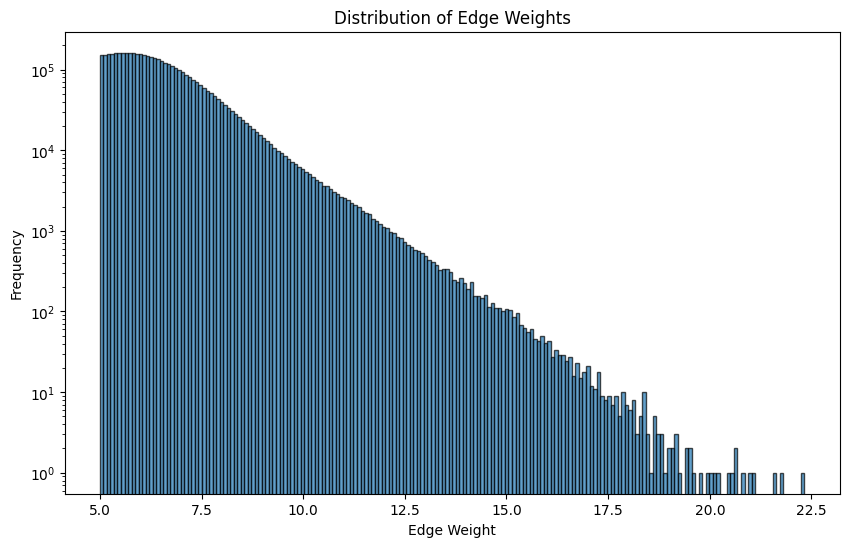

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(edge_weights, bins=200, edgecolor='black', alpha=0.7)
plt.xlabel('Edge Weight')
plt.ylabel('Frequency')
plt.title('Distribution of Edge Weights')
plt.yscale('log')  # Often useful for power-law-like network weights
plt.show()

### End of patrick stuff
***

In [63]:
# replogle grn

# network file
with open('../SCENIC_GRNs/SCENIC_GRNs/networks/repogle_network.json', 'r') as json_file:
    network = json.load(json_file)
    
# Create the networkx graph
G = nx.DiGraph()
for tf, targets in network.items():
    for target, weight in targets:
        G.add_edge(tf, target, weight=weight)

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1
gene_list = list(G.nodes)

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

# filtering data to gene contained in the network G
adata.var_names = adata.var['gene_name'].astype(str)
adata.var_names_make_unique()
adata = adata[:, adata.var_names.isin(gene_list)]

# perturbation filtering
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')
perts_not_included = [pert for pert in perturbations if not pert in gene_list]
adata = adata[~adata.obs['target_gene'].isin(perts_not_included)].copy()

# adata rows shuffle (otherwise perturbations are all ordered)
adata = adata[np.random.permutation(adata.n_obs), :].copy()
adata

Number of nodes: 3390
Number of edges: 11995
Number of node features per node: 1


AnnData object with n_obs × n_vars = 52525 × 3390
    obs: 'target_gene', 'cell_type', 'cov_drug_dose_name', 'dose_val', 'control', 'condition_name'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'

In [9]:
import pickle

with open("grn_coexpression_vcc_data.pkl", "rb") as file:
    G = pickle.load(file)
G.number_of_nodes()

18080

In [10]:
genes_not_included = [gene for gene in gene_list if gene not in list(G.nodes)] # some genes of gene_list are not included!
G.add_nodes_from(genes_not_included)
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
num_features = 1

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

Number of nodes: 18080
Number of edges: 358399
Number of node features per node: 1


Setting up compatibility between the networkx graph G and the adata file...

In [11]:
#TODO: I should recompute the GRN....
nodes_to_remove = [node for node in G.nodes() if node not in gene_list]
G.remove_nodes_from(nodes_to_remove)
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Number of node features per node:", num_features)

Number of nodes: 18020
Number of edges: 357992
Number of node features per node: 1


In [11]:
# check if the node names of th enwtrokx graph aorresponds to adata.var_names
assert set(G.nodes) == set(adata.var_names), "Nodes in G and adata.var_names differ!"

In [12]:
# relabel networkx node indices to match the adata
gene_to_idx = {node: i for i, node in enumerate(adata.var_names)}
G = nx.relabel_nodes(G, gene_to_idx)
edge_index = from_networkx(G, group_edge_attrs='all').edge_index # this way, edge_index follows the gene order of adata.var_names

### **Dataloaders preparation**
Compared with the original SPECTRA model, here we should calculate the dataloaders so that in each batch there are only samples taken from the same perturbations.

In [22]:
from torch.utils.data.sampler import Sampler
import random

# a special batch sampler that groups only cells from the same interventional distribution into a batch
class SCDATA_sampler(Sampler):
    def __init__(self, data, batchsize, ptb_name=None):
        self.intervindices = []
        self.len = 0
        if ptb_name is None:
            ptb_name = data.perturbations
        for ptb in set(ptb_name):
            idx = np.where(ptb_name == ptb)[0] # indices of cells with the same interventional distribution
            self.intervindices.append(idx) # list of indices of cells with the same interventional distribution
            self.len += len(idx) // batchsize # number of batches
        self.batchsize = batchsize
    
    def __iter__(self):
        comb = []
        # loop over each intervention
        for i in range(len(self.intervindices)):
            random.shuffle(self.intervindices[i]) # intra-Perturbation Shuffle
            interv_batches = chunk(self.intervindices[i], self.batchsize)
            if interv_batches:
                comb += interv_batches

        combined = [batch.tolist() for batch in comb]
        random.shuffle(combined) # shuffle the order of the batches
        return iter(combined)
    
    def __len__(self):
        return self.len


def chunk(indices, chunk_size):
    split = torch.split(torch.tensor(indices), chunk_size) # this divides the torch indices into subsets of equal length chunk_size
    
    if len(indices) % chunk_size == 0:
        return split
    elif len(split) > 0:
        # If there are some indices left over (the last chunk is smaller than chunk_size),
        # this line discards the last chunk. 
        # It returns all the chunks except the last one.
        return split[:-1]
    else:
        return None

In [15]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class PerturbationDataset(Dataset):
    def __init__(self, adata, gene_to_idx, start_idx=0, end_idx=None):
        super().__init__()
        
        self.adata = adata
        self.edge_index = edge_index.share_memory_()  # Share to save memory - this is the "base" GRN
        self.gene_to_idx = gene_to_idx
        self.start_idx = start_idx
        self.end_idx = end_idx if end_idx is not None else len(adata)
        self.X_data = self.adata.X.toarray() if hasattr(self.adata.X, "toarray") else np.asarray(self.adata.X)
        self.X_data = torch.tensor(self.X_data, dtype=torch.float)
        self.condition = self.adata.obs['target_gene']
        self.perturbations = self.condition[self.start_idx:self.end_idx]
        
        # Precompute perturbation map and edge cache
        self.perturb_map = {} # map each pertrub to gene indices

        for gene_str in self.condition.unique():
            temp = torch.zeros(self.adata.shape[1], dtype=torch.bool)
            if gene_str == 'non-targeting': 
                self.perturb_map[gene_str] = temp
            else:
                perturbs = [gene_to_idx[g] for g in gene_str.split('+') if g in gene_to_idx]
                for pert in perturbs:
                    temp[pert]=True
                self.perturb_map[gene_str] = temp# torch.tensor(perturbs, dtype=torch.long)
    
    # Returns the number of examples in your dataset.
    def __len__(self):
        return self.end_idx - self.start_idx
    
    # logic to load a single graph.
    def __getitem__(self, idx):
        
        # Map to actual index in adata
        actual_idx = self.start_idx + idx
        
        cond = self.condition.iloc[actual_idx]
        features = self.X_data[actual_idx].view(-1, 1)
        pert = self.perturb_map[cond]

        return features, pert

# Setup
dataset_size = 100000#adata.X.shape[0] 
test_ratio = 0.20
val_ratio = 0.03
test_size = int(dataset_size * test_ratio)
val_size = int(dataset_size * val_ratio)
train_size = dataset_size - test_size - val_size


# Create datasets
train_dataset = PerturbationDataset(
    adata, gene_to_idx,
    start_idx=0, 
    end_idx=train_size
)

val_dataset = PerturbationDataset(
    adata, gene_to_idx,
    start_idx=train_size, 
    end_idx=train_size+val_size
)

test_dataset = PerturbationDataset(
    adata, gene_to_idx,
    start_idx=train_size+val_size, 
    end_idx=dataset_size
)

N_WORKERS = 4 #TODO this will be passed as an argument to training load dataset
batch_size = 32

# create loaders
train_loader = DataLoader(train_dataset, batch_sampler=SCDATA_sampler(train_dataset, batch_size), num_workers=N_WORKERS, pin_memory=True) #pin memory optimize transfer to CUDA
val_loader = DataLoader(val_dataset, batch_sampler=SCDATA_sampler(val_dataset, batch_size), num_workers=N_WORKERS, pin_memory=True) 
test_loader = DataLoader(test_dataset, batch_sampler=SCDATA_sampler(test_dataset, batch_size), num_workers=N_WORKERS, pin_memory=True) 

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 77000
Test dataset size: 20000
Validation dataset size: 3000


**NOTE**: compared with the one above, this one does not force batches to contain all the same perturbations

In [14]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class PerturbationDataset(Dataset):
    def __init__(self, adata, gene_to_idx, start_idx=0, end_idx=None):
        super().__init__()
        
        self.adata = adata
        self.edge_index = edge_index.share_memory_()  # Share to save memory - this is the "base" GRN
        self.gene_to_idx = gene_to_idx
        self.start_idx = start_idx
        self.end_idx = end_idx if end_idx is not None else len(adata)
        self.X_data = self.adata.X.toarray() if hasattr(self.adata.X, "toarray") else np.asarray(self.adata.X)
        self.X_data = torch.tensor(self.X_data, dtype=torch.float)
        self.condition = self.adata.obs['target_gene']
        self.perturbations = self.condition[self.start_idx:self.end_idx]
        
        # Precompute perturbation map and edge cache
        self.perturb_map = {} # map each pertrub to gene indices

        for gene_str in self.condition.unique():
            temp = torch.zeros(self.adata.shape[1], dtype=torch.bool)
            if gene_str == 'non-targeting': 
                self.perturb_map[gene_str] = temp
            else:
                perturbs = [gene_to_idx[g] for g in gene_str.split('+') if g in gene_to_idx]
                for pert in perturbs:
                    temp[pert]=True
                self.perturb_map[gene_str] = temp# torch.tensor(perturbs, dtype=torch.long)
    
    # Returns the number of examples in your dataset.
    def __len__(self):
        return self.end_idx - self.start_idx
    
    # logic to load a single graph.
    def __getitem__(self, idx):
        
        # Map to actual index in adata
        actual_idx = self.start_idx + idx
        
        cond = self.condition.iloc[actual_idx]
        features = self.X_data[actual_idx].view(-1, 1)
        pert = self.perturb_map[cond]

        return features, pert

# Setup
dataset_size = adata.X.shape[0] 
test_ratio = 0.20
val_ratio = 0.03
test_size = int(dataset_size * test_ratio)
val_size = int(dataset_size * val_ratio)
train_size = dataset_size - test_size - val_size


# Create datasets
train_dataset = PerturbationDataset(
    adata, gene_to_idx,
    start_idx=0, 
    end_idx=train_size
)

val_dataset = PerturbationDataset(
    adata, gene_to_idx,
    start_idx=train_size, 
    end_idx=train_size+val_size
)

test_dataset = PerturbationDataset(
    adata, gene_to_idx,
    start_idx=train_size+val_size, 
    end_idx=dataset_size
)

N_WORKERS = 4 #TODO this will be passed as an argument to training load dataset

# Create loaders - graphs are created on-the-fly!
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=N_WORKERS, pin_memory=True) #pin memory optimize transfer to CUDA
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=N_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=N_WORKERS, pin_memory=True)


# Use as normal
print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 169401
Test dataset size: 43999
Validation dataset size: 6599


In [15]:
#NOTE: new DEGs weights
from WMSE import compute_weights

gene_weights = compute_weights(adata[0:train_size,:], gene_to_idx, cells_per_pert=256)

/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:456: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/scanpy/tools/_rank_g

In [15]:
# DEGs weights 
from WMSE import precompute_wmse_weights

gene_weights = precompute_wmse_weights(adata[0:train_size,:], gene_to_idx, pert_col='target_gene')

Pre-computing WMSE weights (DEGs vs Rest)...


/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:667: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:456: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once usi

In [19]:
# i save this, is a pain everytime to recompute all of this
import pickle
with open('cancella.pkl', 'wb') as file:
    pickle.dump(gene_weights, file)

In [18]:
import pickle
with open("cancella.pkl", "rb") as file:
    gene_weights = pickle.load(file)

### **Model setup**

In [16]:
from spectra_2v import PerturbModel

model = PerturbModel(
    edge_index, 
    num_nodes, 
    device, 
    gene_weights=gene_weights, 
    num_node_features=1, 
    n_channels=24, 
    edge_dropout_p=0.2
)
model = model.to(device)
print(model)

PerturbModel(
  (encoder): VariationalGraphEncoder(
    (conv1): DirGNNConv(ChebConv(1, 24, K=3, normalization=sym), alpha=0.5)
    (ln1): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
    (conv2): DirGNNConv(ChebConv(24, 48, K=3, normalization=sym), alpha=0.5)
    (ln2): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
    (conv_mu): DirGNNConv(ChebConv(48, 24, K=2, normalization=sym), alpha=0.5)
    (conv_logstd): DirGNNConv(ChebConv(48, 24, K=2, normalization=sym), alpha=0.5)
  )
  (gex_decoder): FeatureDecoder(
    (conv1): DirGNNConv(ChebConv(24, 24, K=3, normalization=sym), alpha=0.5)
    (ln1): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
    (conv2): DirGNNConv(ChebConv(24, 24, K=3, normalization=sym), alpha=0.5)
    (ln2): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
    (last_layer): MLP(
      (network): Sequential(
        (0): Dropout(p=0.1, inplace=False)
        (1): Linear(in_features=24, out_features=24, bias=True)
        (2): BatchNorm1d(24

In [17]:
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'number of parameters: {num_trainable_params}')

number of parameters: 29259


In [18]:
import gc

gc.collect()
torch.cuda.empty_cache()

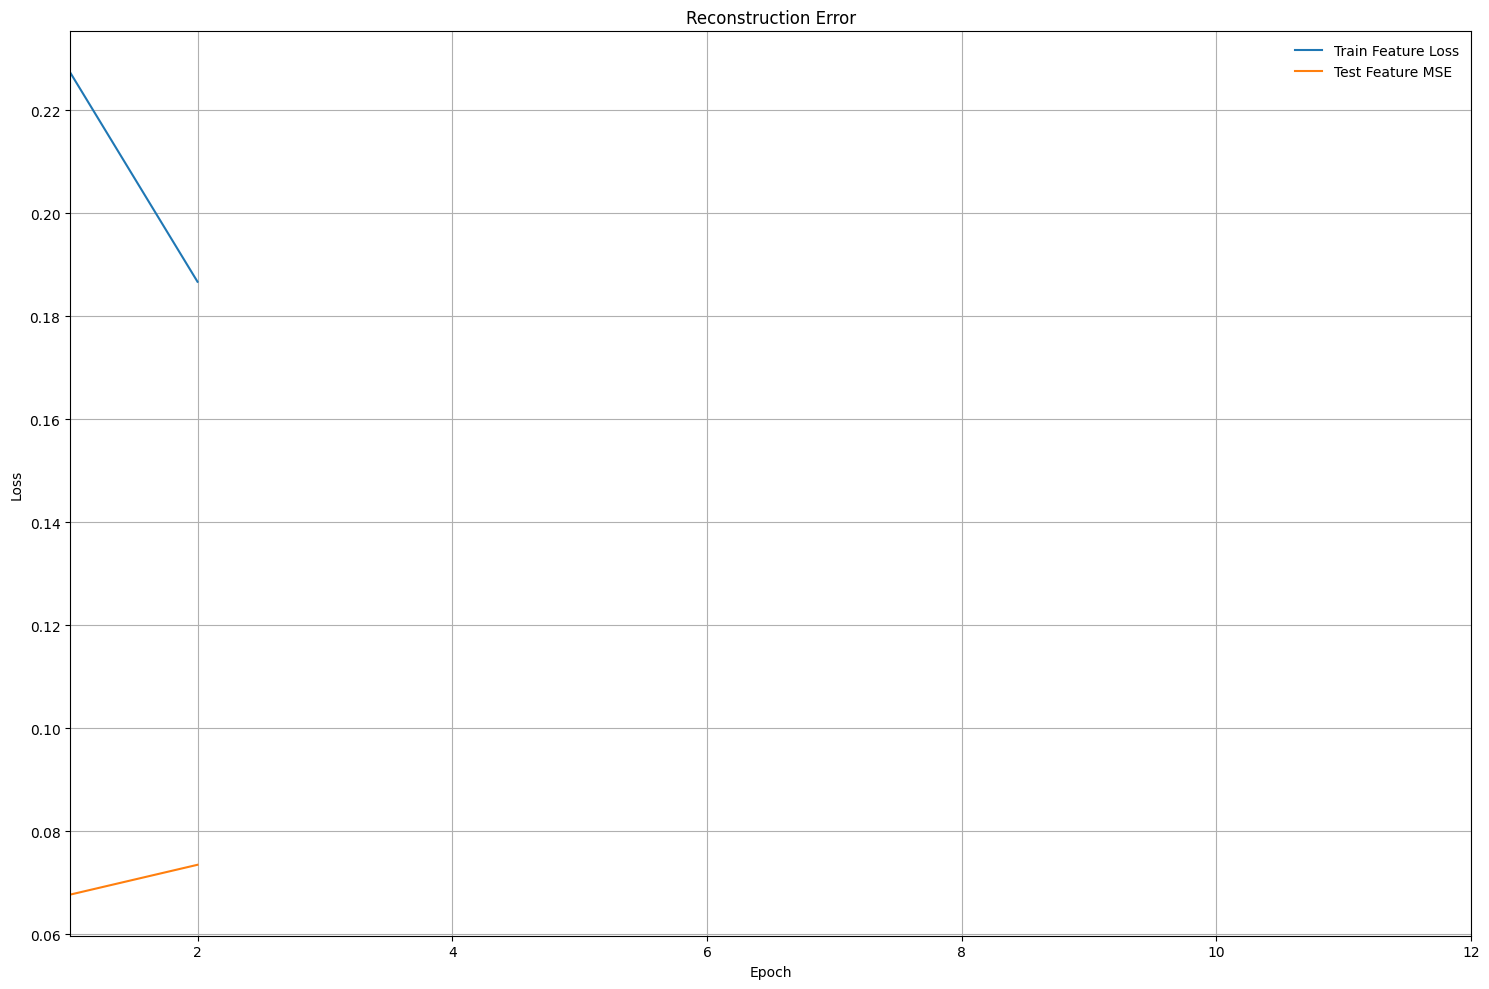

test performances at epoch: 002 | WMSE (Train): 0.186663 | MSE (Test): 0.073469 | KL: 1.203345


training at epoch 3:   2%|▏         | 85/5294 [00:41<41:54,  2.07it/s] 


KeyboardInterrupt: 

In [18]:
#from model_v3_efficient import train
from spectra_2v import train
feat_train_loss, _, feat_test_values = train(model=model, 
    train_loader=train_loader, 
    test_loader=val_loader,
    lr=0.003, 
    n_epochs=12, 
    device=device, 
    live_plot=True)

In [29]:
torch.save(model.state_dict(), "test_25_gen.pth")

***

### **Testing**

In [26]:
model.load_state_dict(torch.load("temp_weights_epoch_9.pth"))

/localscratch/30929727.michele.calabro/ipykernel_572238/614245259.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("temp_weights_epoch_9.

<All keys matched successfully>

In [19]:
model.eval()

PerturbModel(
  (encoder): VariationalGraphEncoder(
    (conv1): DirGNNConv(ChebConv(1, 24, K=3, normalization=sym), alpha=0.5)
    (ln1): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
    (conv2): DirGNNConv(ChebConv(24, 48, K=3, normalization=sym), alpha=0.5)
    (ln2): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
    (conv_mu): DirGNNConv(ChebConv(48, 24, K=2, normalization=sym), alpha=0.5)
    (conv_logstd): DirGNNConv(ChebConv(48, 24, K=2, normalization=sym), alpha=0.5)
  )
  (gex_decoder): FeatureDecoder(
    (conv1): DirGNNConv(ChebConv(24, 24, K=3, normalization=sym), alpha=0.5)
    (ln1): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
    (conv2): DirGNNConv(ChebConv(24, 24, K=3, normalization=sym), alpha=0.5)
    (ln2): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
    (last_layer): MLP(
      (network): Sequential(
        (0): Dropout(p=0.1, inplace=False)
        (1): Linear(in_features=24, out_features=24, bias=True)
        (2): BatchNorm1d(24

In [20]:
from tqdm import tqdm
from scipy import sparse
import anndata as ad

In [22]:
# technical duplicates
indices_1 = []
indices_2 = []
for gene, idx in adata.obs.groupby("target_gene").indices.items():
    idx = np.array(idx) # list of indices associated to gene
    half = len(idx) // 2
    indices_1.extend(idx[:half])
    indices_2.extend(idx[half:])
real_adata = adata[indices_1].copy()
pred_adata = adata[indices_2].copy()


/localscratch/29440558.michele.calabro/ipykernel_878365/8321379.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for gene, idx in adata.obs.groupby("target_gene").indices.items():


In [21]:
n_cells = len(test_dataset)
real_adata = adata[-n_cells:, :]
real_adata

View of AnnData object with n_obs × n_vars = 43999 × 3406
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

In [22]:
counts = real_adata.obs['target_gene'].value_counts()
valid_pert = counts[counts >= 100].index
real_adata = real_adata[real_adata.obs['target_gene'].isin(valid_pert)]
real_adata

View of AnnData object with n_obs × n_vars = 42566 × 3406
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

In [23]:
# creation of dict: for each pertuyrbation how many cells to generate
counts = real_adata.obs['target_gene'].value_counts()
counts = counts[counts >= 100]
#gene_counts_dict = counts.drop('non-targeting').to_dict()
gene_counts_dict = counts.to_dict()

In [24]:
def generate_adata_from_control(gene_counts_dict, real_adata, model, gene_to_idx, var_names):

    prediction_list = []
    obs_gene_list = []

    # control selection
    real_adata_control = real_adata[real_adata.obs['target_gene']=='non-targeting']

    # real_adata processing (delta calculation)
    ctrl_data = real_adata_control.X.toarray() if hasattr(real_adata_control.X, "toarray") else np.asarray(real_adata_control.X)
    ctrl_data = torch.tensor(ctrl_data, dtype=torch.float)

    for pert, n_samples in tqdm(gene_counts_dict.items()):

        # perturbation one-hot embedding
        pert_embedding = torch.zeros(adata.shape[1], dtype=torch.bool)
        if pert!='non-targeting':
            perturbs = [gene_to_idx[g] for g in pert.split('+') if g in gene_to_idx] #NOTE: this takes into account multi-genes pertrurbations
            for single_pert in perturbs:
                pert_embedding[single_pert]=True
            pert_embedding = pert_embedding.unsqueeze(0)
            
        # sampling random control cell
        for i in range(n_samples):
            ctrl_sample = ctrl_data[np.random.randint(0, ctrl_data.shape[0], 1), :].reshape(-1,1).unsqueeze(0)
            # run model
            data = ctrl_sample, pert_embedding
            predicted_full_gex = model.predict_full_expression(data).reshape(1,-1).detach().cpu()
            prediction_list.append(predicted_full_gex.numpy()) 
            obs_gene_list.append(pert)

        
    # Stack all (1, N) vectors → shape (total_cells, N)
    X = np.vstack(prediction_list)

    # Build obs dataframe
    obs = pd.DataFrame({
        "target_gene": obs_gene_list
    })

    # Build var dataframe (gene names)
    var = pd.DataFrame(index=var_names)   # length N list of gene names

    pred_adata = ad.AnnData(X=X, obs=obs, var=var)
    return pred_adata

In [25]:
pred_adata = generate_adata_from_control(gene_counts_dict, real_adata, model, gene_to_idx, real_adata.var_names)
pred_adata

  7%|▋         | 8/120 [03:49<28:21, 15.19s/it]   

In [34]:
from scores import MAE_error
from scores import corr_error

MAE_error(real_adata, pred_adata)

{'TFAM': np.float32(0.15467697), 'UQCRQ': np.float32(0.15207502), 'TMSB4X': np.float32(0.15241891), 'PLCB3': np.float32(0.15196045), 'ACVR1B': np.float32(0.15196323), 'SLC25A3': np.float32(0.15196979), 'RNF2': np.float32(0.15471828), 'METTL17': np.float32(0.15460768), 'USP22': np.float32(0.14980072), 'FOXH1': np.float32(0.1531179), 'STAT1': np.float32(0.15070118), 'IGF2R': np.float32(0.15101498), 'ZNF593': np.float32(0.15139171), 'TSC22D4': np.float32(0.15180977), 'non-targeting': np.float32(0.15122803), 'DHX36': np.float32(0.15987153), 'HMGB2': np.float32(0.15117939), 'TGFBR2': np.float32(0.15619698), 'TRAM2': np.float32(0.15091315), 'CREG1': np.float32(0.15209843), 'SIX4': np.float32(0.1519045), 'MTA1': np.float32(0.15308252), 'INSIG1': np.float32(0.15442482), 'CAMSAP2': np.float32(0.15152356), 'METTL14': np.float32(0.17736042), 'ZNF426': np.float32(0.15311527), 'UBE3C': np.float32(0.15010269), 'DAXX': np.float32(0.15174533), 'EID2': np.float32(0.15141724), 'MAPKAPK2': np.float32(0.1

In [56]:
from scores import corr_error

corr_error(real_adata, pred_adata)

/scratch/michele.calabro/gears/VCC/SPECTRA/scores.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  if not isinstance(selected_real, np.ndarray):


{'non-targeting': np.float32(0.0005274407), 'PBX1': np.float32(0.0013389384), 'TET1': np.float32(0.00082924135), 'WFS1': np.float32(-0.0006525969), 'TADA1': np.float32(-0.00078894076), 'TMSB4X': np.float32(0.0005363976), 'KIF1B': np.float32(-0.0005506254), 'STAT1': np.float32(0.000981497), 'ATP1B1': np.float32(-0.0015371098), 'MED13L': np.float32(-0.0012016584), 'MED13': np.float32(0.0021515556), 'MED12': np.float32(0.0021048577), 'PRCP': np.float32(-9.388628e-05), 'NISCH': np.float32(0.0037123412), 'IGF2R': np.float32(0.00032974742), 'KAT2A': np.float32(0.0012228496), 'HIRA': np.float32(0.0012695721), 'USP22': np.float32(0.0021722796), 'SRC': np.float32(-0.0013246437), 'NCK2': np.float32(-0.0023529222), 'CAST': np.float32(0.003011896), 'KDR': np.float32(0.00037369994)}
=====
average over all the perturbations: 0.0005481786793097854


In [35]:
from scores import RobustDES

des_calculator = RobustDES(lfc_threshold=0.5, alpha=0.05)

assert set(real_adata.obs['target_gene'].unique()) == set(pred_adata.obs['target_gene'].unique()), "perturbations do not match"

perts = [pert for pert in real_adata.obs['target_gene'].unique() if pert != 'non-targeting']
scores = {}
for pert in perts:
    scores[pert] = des_calculator.calculate_f1_score(real_adata, pred_adata, 'target_gene', pert, 'non-targeting')
    print(f'score: {scores[pert]}')
    print('---------------------')
global_score = sum(scores.values())/len(scores)
print(f'average score: {global_score}')

pert TFAM - n_true = 73, n_pred = 1
score: 0.02702702675310446
---------------------
pert UQCRQ - n_true = 29, n_pred = 1
score: 0.06666666597777778
---------------------
pert TMSB4X - n_true = 1, n_pred = 1
score: 0.9999999850000002
---------------------
pert PLCB3 - n_true = 2, n_pred = 1
score: 0.6666666577777778
---------------------
pert ACVR1B - n_true = 18, n_pred = 1
score: 0.1052631567867036
---------------------
pert SLC25A3 - n_true = 19, n_pred = 1
score: 0.09999999895000002
---------------------
pert RNF2 - n_true = 267, n_pred = 1
score: 0.007462686492258855
---------------------
pert METTL17 - n_true = 67, n_pred = 1
score: 0.02941176440743945
---------------------
pert USP22 - n_true = 24, n_pred = 1
score: 0.07999999916799999
---------------------
pert FOXH1 - n_true = 27, n_pred = 1
score: 0.0714285706887755
---------------------
pert STAT1 - n_true = 5, n_pred = 1
score: 0.33333332944444444
---------------------
pert IGF2R - n_true = 5, n_pred = 1
score: 0.3333333294

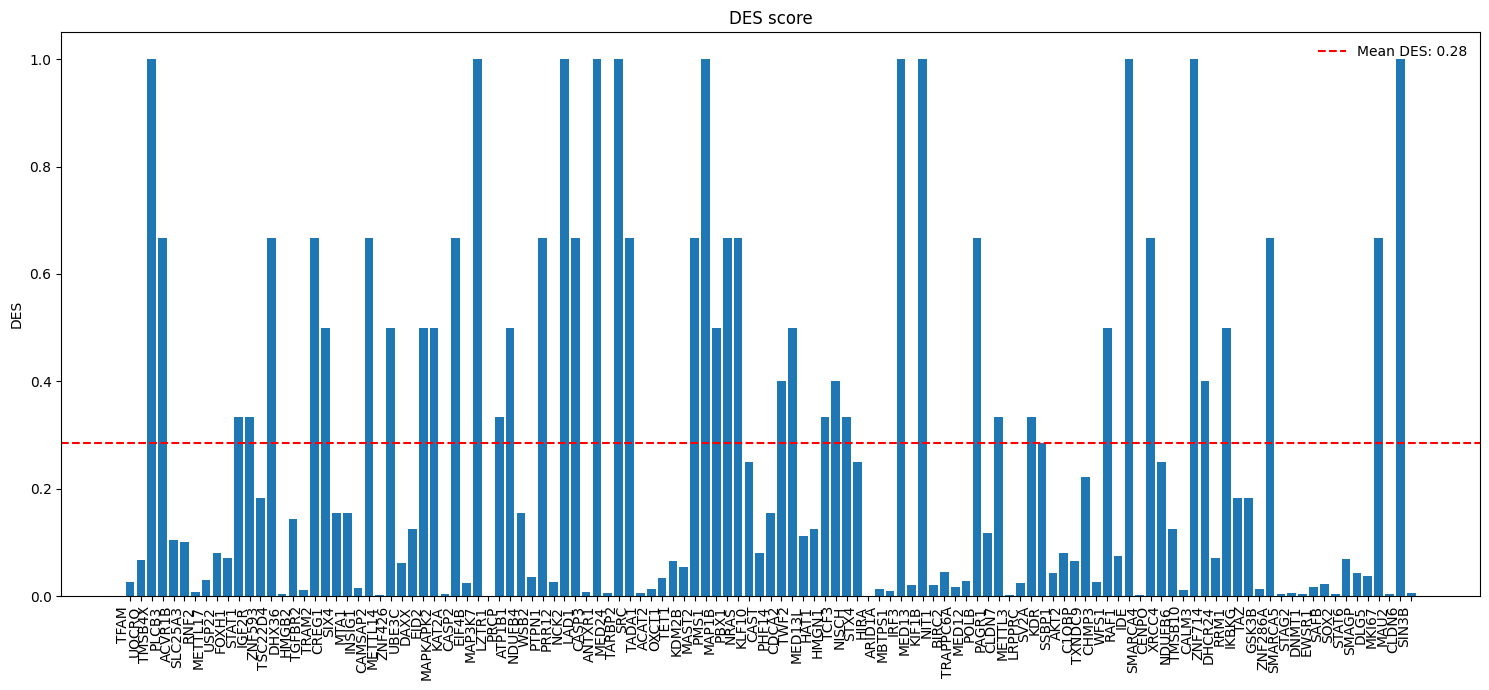

In [36]:
values = list(scores.values())

mean_score = sum(values) / len(values)  # Or use statistics.mean(values)

plt.figure(figsize=(15, 7))
bars = plt.bar(perts, values)#, color='steelblue', alpha=0.7)
plt.xticks(rotation=90, ha='right')  # Vertical labels like your plot
plt.axhline(y=mean_score, color='red', linestyle='--', label=f'Mean DES: {global_score:.2f}')
plt.ylabel('DES')
plt.title('DES score')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

100%|██████████| 20/20 [01:54<00:00,  5.71s/it]


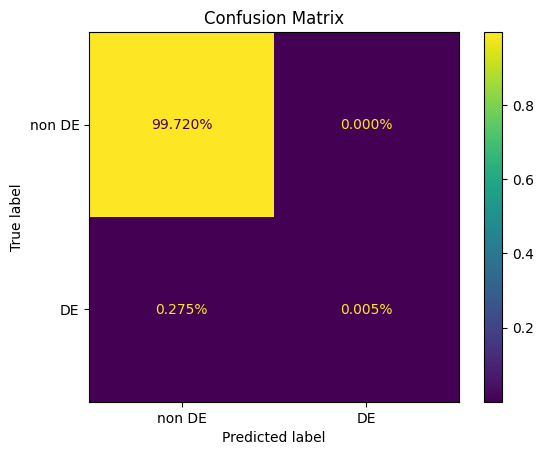

array([[9.97200333e-01, 2.77469478e-06],
       [2.74694784e-03, 4.99445061e-05]])

In [33]:
des_calculator.DES_confusion_matrix(perts,real_adata,pred_adata,'target_gene', 'non-targeting')

/localscratch/29457922.michele.calabro/ipykernel_873807/1463717486.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  real_adata.obs['dataset'] = 'Ground Truth'
/localscratch/29457922.michele.calabro/ipykernel_873807/1463717486.py:9: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_combined = real_adata[real_adata.obs['target_gene']=='non-targeting'].concatenate(
/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1730: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  out = concat(
/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https

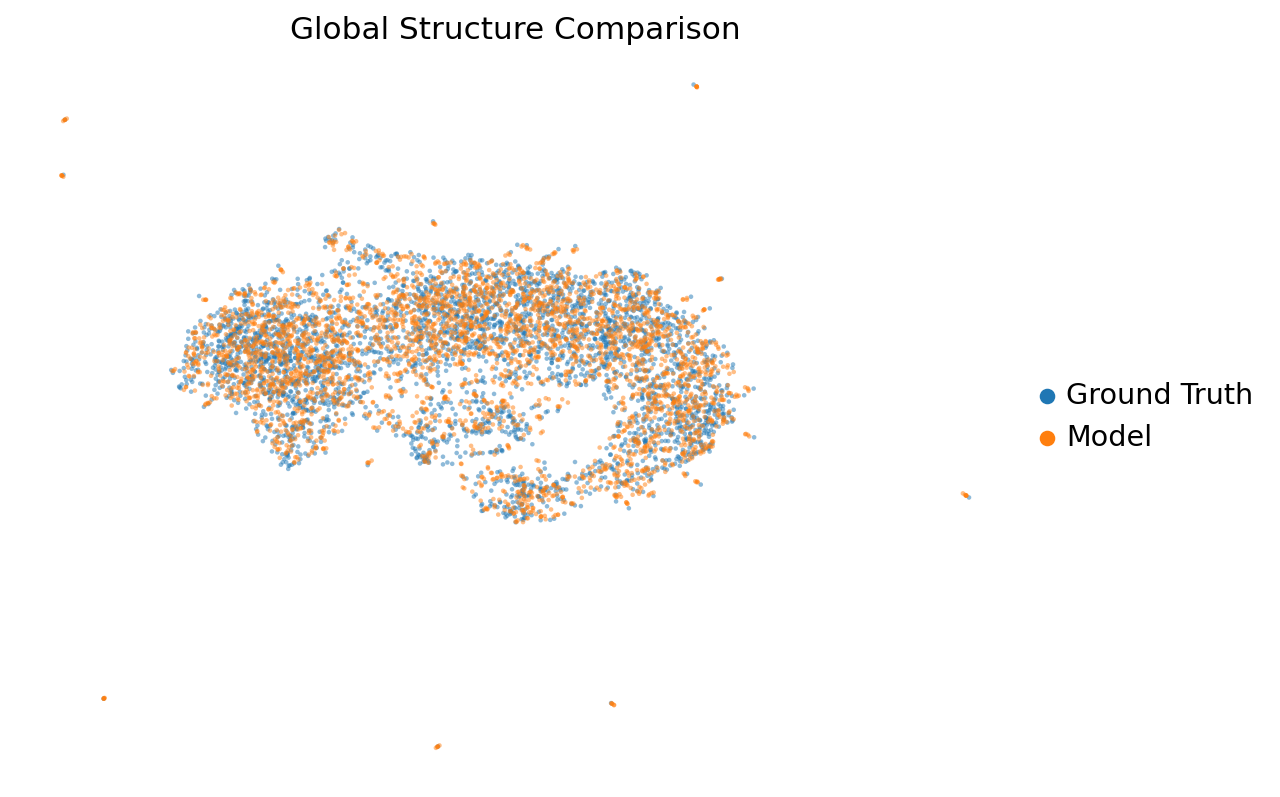

In [59]:
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Label your datasets
real_adata.obs['dataset'] = 'Ground Truth'
pred_adata.obs['dataset'] = 'Model'

# 2. Concatenate them
adata_combined = real_adata[real_adata.obs['target_gene']=='non-targeting'].concatenate(
    pred_adata[pred_adata.obs['target_gene']=='non-targeting'],
    batch_key='source',
    index_unique='-'
)

# 3. Compute embeddings
sc.pp.pca(adata_combined)
sc.pp.neighbors(adata_combined)
sc.tl.umap(adata_combined)   # <-- FIXED

# 4. Plot
sc.set_figure_params(figsize=(8, 6))
sc.pl.umap(
    adata_combined,
    color=['dataset'],
    alpha=0.5,
    title="Global Structure Comparison",
    frameon = False,
    #save = "umap.pdf"
)


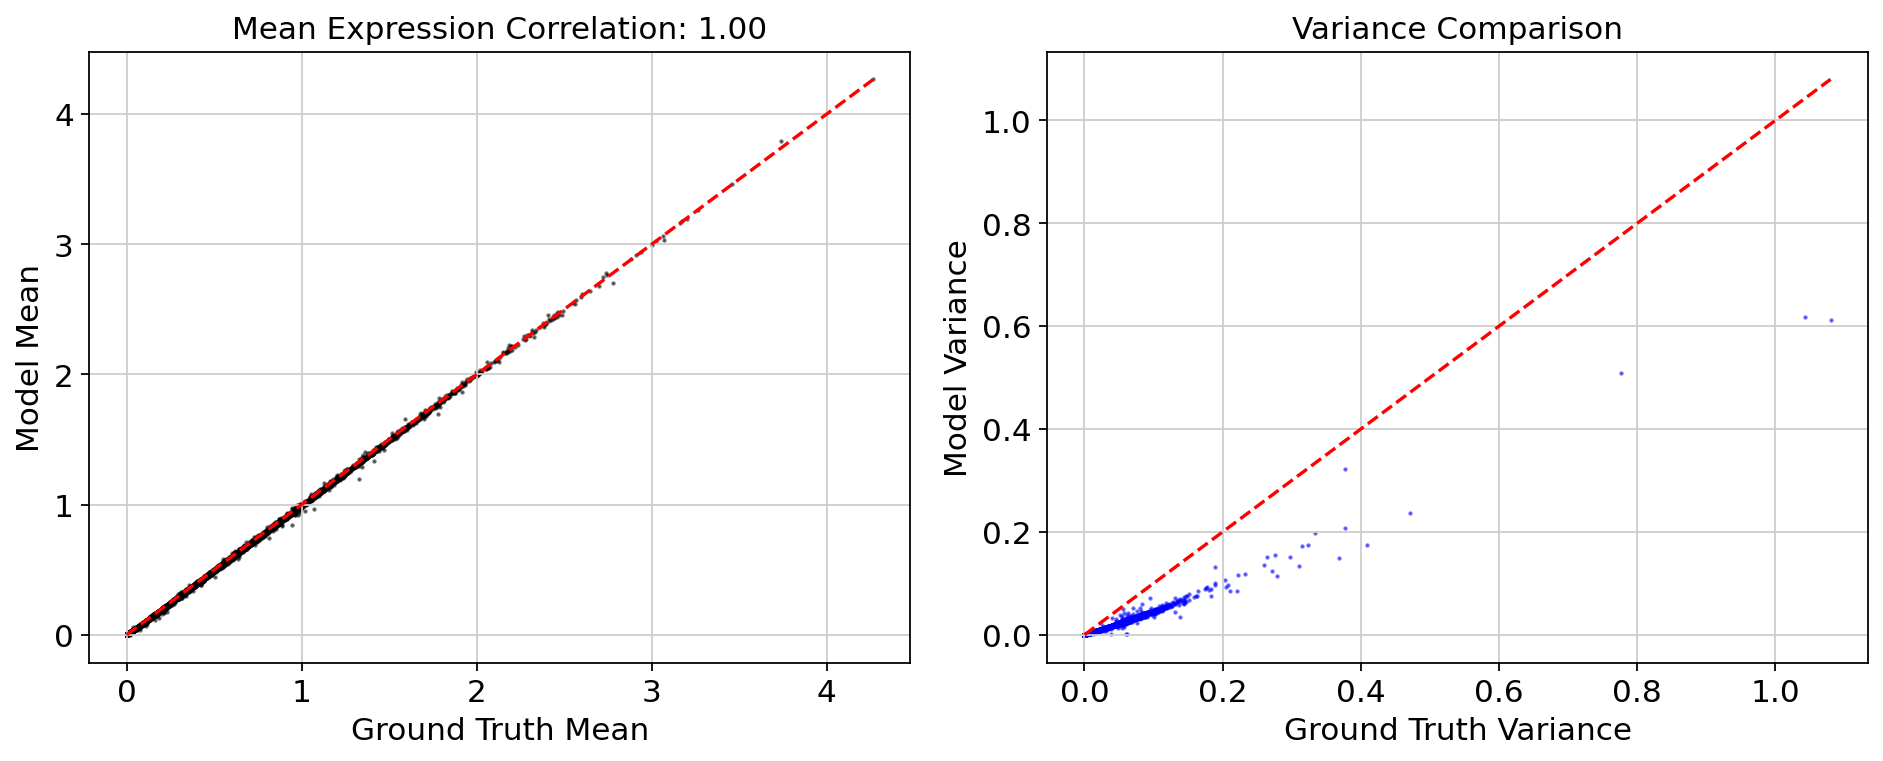

In [60]:
import numpy as np
import seaborn as sns

# Helper function to get mean expression per gene
def get_gene_metrics(adata):
    # Handle sparse matrices if necessary
    if hasattr(adata.X, "toarray"):
        X = adata.X.toarray()
    else:
        X = adata.X
    
    mean_exp = np.mean(X, axis=0)
    var_exp = np.var(X, axis=0)
    return mean_exp, var_exp

gt_mean, gt_var = get_gene_metrics(real_adata)
model_mean, model_var = get_gene_metrics(pred_adata)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Mean Expression
ax[0].scatter(gt_mean, model_mean, s=1, alpha=0.5, c='k')
ax[0].plot([0, max(gt_mean)], [0, max(gt_mean)], 'r--') # Diagonal
ax[0].set_xlabel("Ground Truth Mean")
ax[0].set_ylabel("Model Mean")
ax[0].set_title(f"Mean Expression Correlation: {np.corrcoef(gt_mean, model_mean)[0,1]:.2f}")

# Plot 2: Variance (Dispersion)
ax[1].scatter(gt_var, model_var, s=1, alpha=0.5, c='b')
ax[1].plot([0, max(gt_var)], [0, max(gt_var)], 'r--') # Diagonal
ax[1].set_xlabel("Ground Truth Variance")
ax[1].set_ylabel("Model Variance")
ax[1].set_title("Variance Comparison")

plt.tight_layout()
plt.show()

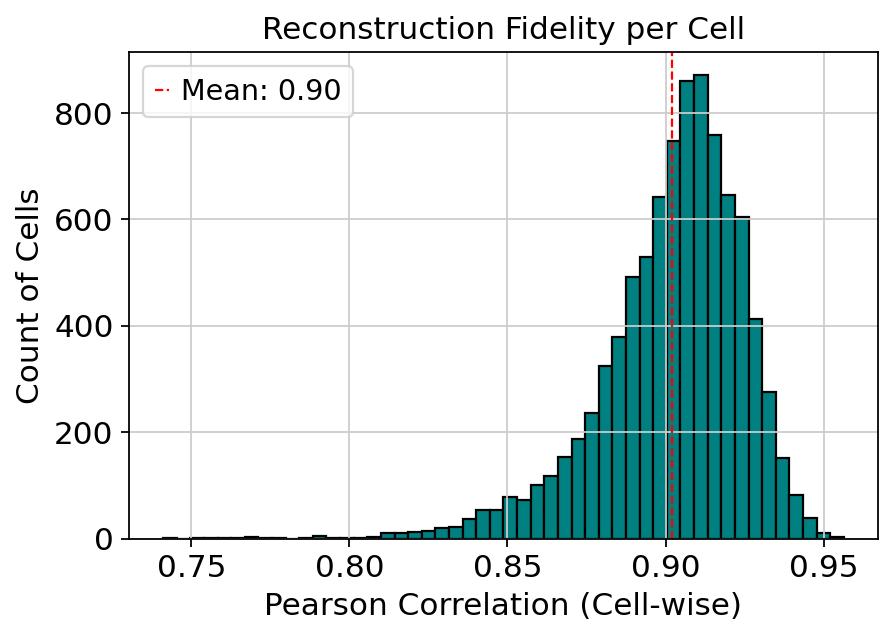

In [61]:
from scipy.stats import pearsonr

correlations = []
n_cells = pred_adata.shape[0]

# Convert to dense once if memory allows, or iterate carefully
X_gt = real_adata.X if not hasattr(real_adata.X, "toarray") else real_adata.X.toarray()
X_model = pred_adata.X if not hasattr(pred_adata.X, "toarray") else pred_adata.X.toarray()

for i in range(n_cells):
    # Calculate correlation for cell i
    corr, _ = pearsonr(X_gt[i], X_model[i])
    correlations.append(corr)

# Plot Histogram of Correlations
plt.figure(figsize=(6, 4))
plt.hist(correlations, bins=50, color='teal', edgecolor='black')
plt.xlabel("Pearson Correlation (Cell-wise)")
plt.ylabel("Count of Cells")
plt.title("Reconstruction Fidelity per Cell")
plt.axvline(np.mean(correlations), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(correlations):.2f}')
plt.legend()
plt.show()

***

### **Generative model - please work**

In [41]:
def generate_adata(perts_x_ncells, model, gene_to_idx, var_names):
    prediction_list = []
    obs_gene_list = []

    # for each perturbation....
    for pert in perts_x_ncells.keys():
        if pert != "non-targeting":
            print(pert)

            # how many cells are in the real data and I have to generate with the generative model?
            n_cells = perts_x_ncells[pert]

            # index corresponding to the pert
            ko_gene_idx = gene_to_idx[pert]

            # generate n_cell perturbed cells
            for j in range(n_cells):
                _, predicted_full_gex = model.generative_prediction(ko_gene_idx)
                predicted_full_gex = predicted_full_gex.reshape(1,-1).detach().cpu()
                prediction_list.append(predicted_full_gex.numpy()) 
                obs_gene_list.append(pert)

    # Stack all (1, N) vectors → shape (total_cells, N)
    X = np.vstack(prediction_list)

    # Build obs dataframe
    obs = pd.DataFrame({
        "target_gene": obs_gene_list
    })

    # Build var dataframe (gene names)
    var = pd.DataFrame(index=var_names)   # length N list of gene names

    pred_adata = ad.AnnData(X=X, obs=obs, var=var)
    return pred_adata

In [42]:
counts = real_adata.obs['target_gene'].value_counts()
counts = counts[counts >= 200]

# Remove 'non-targeting'
gene_counts_dict = counts.drop('non-targeting').to_dict()
del counts

pred_adata2 = generate_adata(gene_counts_dict, model, gene_to_idx, real_adata.var_names)
pred_adata2


TADA1
TMSB4X
PRCP
HIRA
MED12
IGF2R
NCK2
MED13
SRC
PBX1
STAT1
KIF1B
USP22
TET1
KDR
MED13L
ATP1B1
CAST
NISCH
WFS1
KAT2A


/share/apps/spack/latest-2024-01-30/linux-centos8-skylake_avx512/gcc-10.4.0/python-3.11.9-645u3edsk7muarwsj2hfdzf4yukcr4np/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 5474 × 18020
    obs: 'target_gene'

In [28]:
# Filter for non-targeting
ntc_adata = real_adata[real_adata.obs["target_gene"] == "non-targeting"]

# Append the non-targeting controls to the example anndata if they're missing
if "non-targeting" not in pred_adata2.obs["target_gene"].unique():
    assert np.all(pred_adata2.var_names.values == ntc_adata.var_names.values), (
        "Gene-Names are out of order or unequal"
    )
    pred_adata = ad.concat(
        [
            pred_adata2,
            ntc_adata,
        ]
    )
del ntc_adata
pred_adata

/localscratch/29440558.michele.calabro/ipykernel_878365/752534432.py:9: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  pred_adata = ad.concat(


AnnData object with n_obs × n_vars = 9027 × 18020
    obs: 'target_gene'

In [32]:
real_adata

View of AnnData object with n_obs × n_vars = 9027 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

***